# Use Case 4 - Adaptation to Societal Risk of Hydrological Hazards (Floods & Earthquakes) through Schools and Hospitals in Greece - JRC Flood Model

In [1]:
# HIDE CODE
import os
import sys
import gc
import warnings
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import shapes
from rasterstats import point_query
from scipy.stats import lognorm, norm
from shapely.geometry import Point
from shapely import wkt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib import font_manager
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

warnings.filterwarnings("ignore")


## 1. General Comments

- This notebook follows the MIRACA Use Case template structure to ensure consistency across the MIRACA Python Book.
- The workflow is demonstrated for a subset of assets (Schools or Hospitals) within Central Macedonia (Greece).
- Output files are saved in a structured `outputs/` directory to facilitate reproducibility and reuse.

## 2. Introduction

- This Use Case assesses the societal risk of schools and hospitals in Central Macedonia (Greece), considering hydrological hazards (floods) and the combination of floods-earthquakes.

- The analysis combines hazard, exposure, and vulnerability information to estimate potential physical damage for different return periods.

- Relevant stakeholders include: The Civil Protection authorities of the Region of Central Macedonia and the Municipality of Thessaloniki, Greece.

- The results support climate adaptation planning and risk-informed decision-making for critical infrastructures such as educational and healthcare facilities.

## 3. Directory Structure

This notebook assumes the following directory structure:

- `inputs/`  
  Input datasets (exposure, hazard, fragility/vulnerability tables, administrative boundaries).
- `outputs/`  
  Output folder automatically created by the notebook.
  - `outputs/<asset>/Single-Hazard/`  
    Outputs for earthquake-only calculations.
  - `outputs/<asset>/Multi-Hazard/`  
    Outputs for earthquake + landslide calculations.

> Note: `<asset>` is either `Schools` or `Hospitals` depending on the selection below.


Select whether you want to compute the risk assessment for educational buildings (asset = "Schools") or healthcare facilities (asset = "Hospitals").


In [2]:
asset = "Schools"

Define the folder where the data is available and where the results will be saved.

In [ ]:

data_path = Path(os.getcwd()) / "inputs"

savepath = Path(os.getcwd())/ 'outputs' / asset


The following color variables are defined for the Miraca theme. These colors will be used for visualisations. The font settings for the plots are also adjusted for consistency.

In [4]:
# miraca colors
c1 = '#4069F6' # primary blue 500 
c2 = '#171E37' # black
c3 = '#64F4C0' # accent green 
c4 = '#FFFFFF' # white
c5 = '#ED5861' # red
c6 = '#F8CD48' # yellow
c7 = '#72DA95' # green 500
c8 = '#373D52' # grey 900
c9 = '#8F94A3' # grey 500
c10 = '#EBEDF5' # grey 100
c11 = '#72DA95' # green
c12 = '#373D52' # blue 900
c13 = '#6687F8' # blue 400
c14 = '#EBEDF5' # blue 100
c15 = '#373D52' # 429787 900
c16 = '#9CF8D7' # green 400
c17 = '#E0FDF2' # green 100

# Adjust font settings
mpl.rc('font', family='Calibri')
font = {'family': 'Calibri', 'weight': 'bold'}
rcParams['mathtext.default'] = 'regular'
rcParams['mathtext.rm'] = font['family']

## 4. Exposure Assessment

Exposure data correspond to educational and healthcare facilities located in the Region of Central Macedonia, Greece.

- Study area: Region of Central Macedonia, Greece.
- Assets considered: Schools and major healthcare facilities (hospitals).
- Educational facilities achieve high spatial coverage across the study area.
- Healthcare facilities focus on the main hospitals located within the Metropolitan area of Thessaloniki.
- Assets are selected based on the availability of reliable exposure information to ensure robust risk assessment results.

Load exposure data

In [5]:
# Load exposure data
if asset == "Schools":
    csv1_path = data_path / "Exposure_Riskschools.csv"
elif asset == "Hospitals":
    csv1_path = data_path / "Exposure_Hospitals.csv"
else:
    print("Invalid asset type. Please choose either 'Schools' or 'Hospitals'.")
    sys.exit(1)

# Load the CSV files into pandas DataFrames
df1 = pd.read_csv(csv1_path)

# Column names for longitude and latitude
longitude_col1 = 'Longitude'
latitude_col1 = 'Latitude'

# Convert the DataFrames to GeoDataFrames
gdf1 = gpd.GeoDataFrame(df1, geometry=gpd.points_from_xy(df1[longitude_col1], df1[latitude_col1]))

# Set the CRS for both GeoDataFrames to WGS84
gdf1.set_crs(epsg=4326, inplace=True)

,Longitude,Latitude,id,Name,Counsil,Material,Lateral Loading system,Code level,Floors,Lateral Coefficiency,Intensity,Typology,Area,geometry
0,22.538980,40.511320,72,3ο Νηπιαγωγείο Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,Precast,LFINF: infilled frame,CDH,1,NaN,SA(1.5),Precast-CDH,107.60,POINT (22.53898 40.51132)
1,22.543110,40.498490,73,1ο Δημοτικό Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,1,10.0,PGA,CR_LFINF-CDH-10_H1,1008.00,POINT (22.54311 40.49849)
2,22.911365,40.734834,82,1ο Νηπιαγωγείο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,MUR: unreinforced masonry,LWAL: load bearing wall,CDN,1,NaN,PGA,MUR_LWAL-DNO_H1,450.00,POINT (22.91136 40.73483)
3,22.919226,40.723864,83,2ο Γυμνάσιο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,3,15.0,SA(0.6),CR_LFINF-CDH-15_H3,3408.00,POINT (22.91923 40.72386)
4,22.993852,40.612094,84,3ο Δημοτικό Σχολείο Πυλαίας,ΠΥΛΑΙΑΣ-ΧΟΡΤΙΑΤΗ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,PGA,CR_LDUAL-DUH_H2,2010.00,POINT (22.99385 40.61209)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1713,22.456130,40.222693,2024,Λύκειο Κονταριώτισσας - Κτίριο Β,ΔΙΟΥ-ΟΛΥΜΠΟΥ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,PGA,CR_LDUAL-DUH_H2,1024.80,POINT (22.45613 40.22269)
1714,22.456130,40.222693,2025,Λύκειο Κονταριώτισσας - Κτίριο Γ,ΔΙΟΥ-ΟΛΥΜΠΟΥ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,PGA,CR_LDUAL-DUH_H2,1160.90,POINT (22.45613 40.22269)
1715,22.456130,40.222693,2026,Λύκειο Κονταριώτισσας - Κτίριο Δ,ΔΙΟΥ-ΟΛΥΜΠΟΥ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,PGA,CR_LDUAL-DUH_H2,225.36,POINT (22.45613 40.22269)
1716,22.456130,40.222693,2027,Λύκειο Κονταριώτισσας - Κτίριο Ε,ΔΙΟΥ-ΟΛΥΜΠΟΥ,S: steel,LFBR: braced frame,CDH,1,NaN,PGA,S_LFBR-DUH_H1,956.37,POINT (22.45613 40.22269)


Visualise exposure data

In [ ]:
shapefile_path = data_path / 'central macedonia.shp'
gdf_shapefile = gpd.read_file(shapefile_path)

m = gdf_shapefile.explore(
    style_kwds={'color': 'black', 'fillColor': 'lightgray', 'fillOpacity': 0.5},
)

gdf1.explore(
    m=m,
    legend=True,
    legend_kwds={
        'caption': f'{asset} - Central Macedonia',
        'orientation': 'horizontal'
    },
    marker_kwds={'radius': 4, 'fill': True},
)

display(m)

## 5. Hazard Characterisation

Floods

- European Commission - Joint Research Centre (JRC) river flood model (Dottori et al. 2021) in terms of flood depth for six different return periods (Dottori et al. 2021). The JRC model provides a gridded dataset that depicts water depth (in meters) across the river network for nine distinct flood return periods, ranging from 1-in-10 years to 1-in-500 years. River flow data used in the model were generated using the open-source hydrological model LISFLOOD. Flood inundation simulations were conducted with the LISFLOOD-FP hydrodynamic model, focusing on river basins larger than 150 km². This dataset was developed as part of the Copernicus Emergency Management Service initiative.

- Single hazard / Multi-hazards considered 
  - Single hazard: floods
  - Multi-hazard: floods-earthquake

In [8]:
""" This dictionary initializes a DataFrame containing seismic return period data. 
The 'No' column represents a sequential identifier for each flood scenario. 
The 'Return_Period' column specifies the return period in years, 
The resulting DataFrame, Scenaria, captures these flood scenario details. """

data = {'No': [1,2,3,4,5,6,7,8],
        'Return_Period': [10,20,30,40,50,75,100,200]
}

Scenaria = pd.DataFrame(data)

print(Scenaria)

   No  Return_Period
0   1             10
1   2             20
2   3             30
3   4             40
4   5             50
5   6             75
6   7            100
7   8            200


Sample raster values - Flood Hazard

In order to download the flood hazard data, you need to go to the following link and download the JRC flood datasets: [JRC Flood Hazard Data](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-EFAS/flood_hazard/) After downloading the files, place them inside the `inputs` directory in your project folder in order to continue the workflow.

In [9]:
JRC_periods = [10,20,30,40,50,75,100,200]
output_csv = savepath / f"Single-Hazard/Floods/Flood_JRC_hazard_sampled_values_{asset}.csv"

for i in JRC_periods:
    raster_path = data_path / f"Europe_RP{i}_filled_depth.tif"

    # Open the raster file
    with rasterio.open(raster_path) as src:
        # Check NoData value
        nodata_value = src.nodata

        # Ensure CRS matches between the raster and the points
        if gdf1.crs != src.crs:
            gdf1 = gdf1.to_crs(src.crs)

        # Extract coordinates from points
        coords = [(point.x, point.y) for point in gdf1.geometry]

        # Sample raster values at point locations
        sampled_values = []
        for val in src.sample(coords):
            # Replace NoData values with 0
            sampled_values.append(val[0] if val[0] != nodata_value else 0)

    # Add the sampled raster values as a new column in the GeoDataFrame
    gdf1[f'JRC_{i}'] = sampled_values

# Save the updated GeoDataFrame with all raster columns to a CSV file
gdf1.to_csv(output_csv, index=False)

Visualise Flood Hazard Data

In [ ]:
# Plot each flood scenario
for i in JRC_periods:
    m = gdf_shapefile.explore(
        style_kwds={'color': 'black', 'fillColor': 'lightgray', 'fillOpacity': 0.5},
        name='Central Macedonia'
    )

    gdf1.explore(
        m=m,
        column=f'JRC_{i}',
        cmap='GnBu',
        legend=True,
        legend_kwds={
            'caption': f'Flood depth (m) – RP {i} years',
            'orientation': 'horizontal'
        },
        marker_kwds={'radius': 4, 'fill': True},
    )

    display(m)

## 6. Combined Exposure and Hazard Dataset

Exposure points are linked with the corresponding flood intensity measures. 
The resulting dataset combines exposure and flood hazard and is used as input for the subsequent vulnerability and risk assessment steps.

In [13]:
# Load Exposure and Hazard Data
df = pd.read_csv(output_csv)
df.head()

,Longitude,Latitude,id,Name,Counsil,Material,Lateral Loading system,Code level,Floors,Lateral Coefficiency,...,Area,geometry,JRC_10,JRC_20,JRC_30,JRC_40,JRC_50,JRC_75,JRC_100,JRC_200
0,22.538980,40.511320,72,3ο Νηπιαγωγείο Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,Precast,LFINF: infilled frame,CDH,1,NaN,...,107.6,POINT (22.53898 40.51132),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.543110,40.498490,73,1ο Δημοτικό Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,1,10.0,...,1008.0,POINT (22.54311 40.49849),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.911365,40.734834,82,1ο Νηπιαγωγείο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,MUR: unreinforced masonry,LWAL: load bearing wall,CDN,1,NaN,...,450.0,POINT (22.9113646 40.7348339),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,22.919226,40.723864,83,2ο Γυμνάσιο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,3,15.0,...,3408.0,POINT (22.9192263 40.7238642),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22.993852,40.612094,84,3ο Δημοτικό Σχολείο Πυλαίας,ΠΥΛΑΙΑΣ-ΧΟΡΤΙΑΤΗ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,...,2010.0,POINT (22.993852 40.6120941),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Vulnerability Assessment

Flood vulnerability of educational and healthcare facilities is assessed using building-class specific fragility functions (Huizinga et al. 2017; Batica et al. 2018; Nofal and van de Lindt, 2020).
Fragility functions by Nofal and van de Lindt are applied for one-storey and two-storey schools and hospitals, defined in terms of flood depth. They cover five damage states (DS0–DS4), from insignificant to complete damage. Mean flood losses are estimated using the fragility-based flood loss approach for 8 return periods (10–200 years) with the JRC hazard model.

Calculate the fragility value based on conditions

In [14]:
def calculate_value(row):
    if asset == "Hospitals":
        return "F12"  # If asset is Hospital, return F12
    elif row["Floors"] == 1:
        return "F10"  # If Floors == 1, return F10
    elif row["Floors"] >= 2:
        return "F11"  # If Floors >= 2, return F11
    else:
        return 0  # Default value for other cases

# Apply the function to the DataFrame and create a new column
df["Fragility_code"] = df.apply(calculate_value, axis=1)

# Display the updated DataFrame
df.head()

,Longitude,Latitude,id,Name,Counsil,Material,Lateral Loading system,Code level,Floors,Lateral Coefficiency,...,geometry,JRC_10,JRC_20,JRC_30,JRC_40,JRC_50,JRC_75,JRC_100,JRC_200,Fragility_code
0,22.538980,40.511320,72,3ο Νηπιαγωγείο Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,Precast,LFINF: infilled frame,CDH,1,NaN,...,POINT (22.53898 40.51132),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F10
1,22.543110,40.498490,73,1ο Δημοτικό Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,1,10.0,...,POINT (22.54311 40.49849),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F10
2,22.911365,40.734834,82,1ο Νηπιαγωγείο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,MUR: unreinforced masonry,LWAL: load bearing wall,CDN,1,NaN,...,POINT (22.9113646 40.7348339),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F10
3,22.919226,40.723864,83,2ο Γυμνάσιο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,3,15.0,...,POINT (22.9192263 40.7238642),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F11
4,22.993852,40.612094,84,3ο Δημοτικό Σχολείο Πυλαίας,ΠΥΛΑΙΑΣ-ΧΟΡΤΙΑΤΗ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,...,POINT (22.993852 40.6120941),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F11


Extract values for fragility 

In [15]:
# Load ESRM20 data
Nofal = pd.read_excel(data_path/"Nofal_fragility_curves.xlsx")
Nofal.columns = ['Fragility_code', 'Median_DS1', 'Median_DS2', 'Median_DS3', 'Median_DS4', 'Beta_DS1', "Beta_DS2", "Beta_DS3","Beta_DS4"]

# Initialize lists to store results
IM1 = []
IM2 = []
IM3 = []
IM4 = []
Beta_DS1 = []
Beta_DS2 = []
Beta_DS3 = []
Beta_DS4 = []

# Iterate over each value in 'Typology' column of data
for taxonomy in df['Fragility_code']:
    # Check if any row in 'Typology' column matches current taxonomy
    if (Nofal['Fragility_code'] == taxonomy).any():
        # Find the row where 'Typology' matches and retrieve values
        filtered_data = Nofal.loc[Nofal['Fragility_code'] == taxonomy]
        if not filtered_data.empty:
            IM1.append(filtered_data['Median_DS1'].values[0])
            IM2.append(filtered_data['Median_DS2'].values[0])
            IM3.append(filtered_data['Median_DS3'].values[0])
            IM4.append(filtered_data['Median_DS4'].values[0])
            Beta_DS1.append(filtered_data['Beta_DS1'].values[0])
            Beta_DS2.append(filtered_data['Beta_DS2'].values[0])
            Beta_DS3.append(filtered_data['Beta_DS3'].values[0])
            Beta_DS4.append(filtered_data['Beta_DS4'].values[0])
        else:
            # Handle case where no matching Typology is found in ESRM20
            IM1.append(None)
            IM2.append(None)
            IM3.append(None)
            IM4.append(None)
            Beta_DS1.append(None)
            Beta_DS2.append(None)
            Beta_DS3.append(None)            
            Beta_DS4.append(None)
    else:
        # Handle case where no matching Typology is found in ESRM20
        IM1.append(None)
        IM2.append(None)
        IM3.append(None)
        IM4.append(None)
        Beta_DS1.append(None)
        Beta_DS2.append(None)
        Beta_DS3.append(None)            
        Beta_DS4.append(None)

# Create a new DataFrame to store results
IM = pd.DataFrame({
    'IM1': IM1,
    'IM2': IM2,
    'IM3': IM3,
    'IM4': IM4,
    'Beta_DS1': Beta_DS1,
    'Beta_DS2': Beta_DS2,
    'Beta_DS3': Beta_DS3 ,   
    'Beta_DS4': Beta_DS4
})

IM["Fragility_code"]=df["Fragility_code"]
#print(IM)

IM.iloc[:15]

,IM1,IM2,IM3,IM4,Beta_DS1,Beta_DS2,Beta_DS3,Beta_DS4,Fragility_code
0,-1.570,-0.681,0.824,1.573,0.502,0.738,0.531,0.186,F10
1,-1.570,-0.681,0.824,1.573,0.502,0.738,0.531,0.186,F10
2,-1.570,-0.681,0.824,1.573,0.502,0.738,0.531,0.186,F10
3,-1.546,-0.678,1.388,2.006,0.488,0.740,0.435,0.254,F11
4,-1.546,-0.678,1.388,2.006,0.488,0.740,0.435,0.254,F11
5,-1.570,-0.681,0.824,1.573,0.502,0.738,0.531,0.186,F10
6,-1.570,-0.681,0.824,1.573,0.502,0.738,0.531,0.186,F10
7,-1.546,-0.678,1.388,2.006,0.488,0.740,0.435,0.254,F11
8,-1.546,-0.678,1.388,2.006,0.488,0.740,0.435,0.254,F11
9,-1.546,-0.678,1.388,2.006,0.488,0.740,0.435,0.254,F11


## 8. Risk Assessment

Risk metrics are computed by combining hazard intensity measures with exposure and vulnerability information for each flood scenario.

Asset-level damage probabilities and loss ratios are estimated for multiple return periods, followed by the computation of annual collapse probability using the stress-based methodology.

###  Single-hazard risk assessment (floods)

Calculate damage index

In [16]:
from scipy.stats import norm

def calculate_normal_distribution(mean, std_dev):

    # Ensure the standard deviation (std_dev) is positive
    std_dev = abs(std_dev)  # Standard deviation should always be positive
    
    # Create a normal distribution with mean=mean and std_dev=std_dev
    return norm(loc=mean, scale=std_dev)

In [17]:
def compute_cdf_values(row, im_row, return_period):
    """
    Computes CDF values based on the intensity and IM row data for a specific return period.
    
    Parameters:
    - row: A row from the input DataFrame.
    - im_row: A row from the IM DataFrame containing beta and IM values.
    - return_period: The return period (e.g., 10, 20, 30 years) used to identify the intensity column.
    
    Returns:
    - A tuple of computed CDF values (cdf1, cdf2, cdf3, cdf4), or 0 if values are NaN.
    """
    # Dynamically set the column name based on the return period (e.g., JRC_10, JRC_20, etc.)
    column_name = f'JRC_{return_period}'
    
    # Get the intensity value (x_value) from the specified column
    x_value = row[column_name] if column_name in row and not pd.isna(row[column_name]) else np.nan

    # Skip the row if x_value is 0 or NaN
    if pd.isna(x_value) or x_value == 0.0:
        # print(f"Skipping row due to x_value = {x_value} at return period {return_period}")
        return 0.0, 0.0, 0.0, 0.0  # Return 0 for all CDF values

    # Check if any of the IM values are NaN (missing)
    if pd.isna(im_row["IM1"]) or pd.isna(im_row["IM2"]) or pd.isna(im_row["IM3"]) or pd.isna(im_row["IM4"]):
        # print(f"Skipping row due to missing IM values at return period {return_period}")
        return 0.0, 0.0, 0.0, 0.0  # Return 0 for all CDF values
    
    # Define a list of IM values and beta values for each damage state
    im_values = [im_row["IM1"], im_row["IM2"], im_row["IM3"], im_row["IM4"]]
    beta_values = [im_row["Beta_DS1"], im_row["Beta_DS2"], im_row["Beta_DS3"], im_row["Beta_DS4"]]
    
    # Initialize lists to store the CDF values
    cdf_values = []
    
    # Loop through the damage states and calculate CDF values
    for im_value, beta_value in zip(im_values, beta_values):
        # Create normal distributions for each damage state using IM values as means and beta values as std devs
        dist = calculate_normal_distribution(im_value, beta_value)
        
        # Compute the CDF value for the given intensity (x_value) and append to the list
        cdf_val = dist.cdf(np.log(x_value)) if not pd.isna(dist.cdf(np.log(x_value))) else 0.0
        cdf_values.append(cdf_val)
    
    # Return the CDF values for all 4 damage states
    return tuple(cdf_values)

In [18]:
# Create a dictionary to store the CDF results for each return period
cdf_dict = {}

# Iterate over each row in the Scenarios DataFrame (Scenaria)
for index_scen, scen_row in Scenaria.iterrows():
    try:
        # Variables to store CDF results for each damage state
        cdf1, cdf2, cdf3, cdf4 = [], [], [], []
        
        # Scenario parameters
        return_period = int(scen_row['Return_Period'])

        # Iterate over each row in the df DataFrame (your input data)
        for index, row in df.iterrows():
            # Retrieve the corresponding row from the IM DataFrame
            if index < len(IM):
                im_row = IM.iloc[index]

                # Compute CDF values for the specific return period
                cdf1_val, cdf2_val, cdf3_val, cdf4_val = compute_cdf_values(row, im_row, return_period)
                
                # Append the results for each damage state
                cdf1.append(cdf1_val)
                cdf2.append(cdf2_val)
                cdf3.append(cdf3_val)
                cdf4.append(cdf4_val)
            else:
                # Handle potential index mismatch
                cdf1.append(np.nan)
                cdf2.append(np.nan)
                cdf3.append(np.nan)
                cdf4.append(np.nan)

        # Create a DataFrame to store the CDF results for the current scenario
        CDF = pd.DataFrame({
            "Longitude": df["Longitude"],
            "Latitude": df["Latitude"],
            f"CDF1-{return_period}": cdf1,
            f"CDF2-{return_period}": cdf2,
            f"CDF3-{return_period}": cdf3,
            f"CDF4-{return_period}": cdf4
        })
        
        # Calculate the probabilities of occurrence for each damage state
        CDF[f"P_DS1-{return_period}"] = CDF[f"CDF1-{return_period}"] - CDF[f"CDF2-{return_period}"]
        CDF[f"P_DS2-{return_period}"] = CDF[f"CDF2-{return_period}"] - CDF[f"CDF3-{return_period}"]
        CDF[f"P_DS3-{return_period}"] = CDF[f"CDF3-{return_period}"] - CDF[f"CDF4-{return_period}"]
        CDF[f"P_DS4-{return_period}"] = CDF[f"CDF4-{return_period}"]
        
        DI_values = []
        for index, row in df.iterrows():
            # Check Material type and calculate DI accordingly
            # Calculate DI_value based on Fragility Code (F10, F11, F12)
            if row['Fragility_code'] == 'F10':
                DI_value = (
                    CDF.loc[index, f"P_DS1-{return_period}"] * 0.08 +
                    CDF.loc[index, f"P_DS2-{return_period}"] * 0.39 +
                    CDF.loc[index, f"P_DS3-{return_period}"] * 0.72 +
                    CDF.loc[index, f"P_DS4-{return_period}"] * 1
                )
            elif row['Fragility_code'] == 'F11':
                DI_value = (
                    CDF.loc[index, f"P_DS1-{return_period}"] * 0.05 +
                    CDF.loc[index, f"P_DS2-{return_period}"] * 0.24 +
                    CDF.loc[index, f"P_DS3-{return_period}"] * 0.72 +
                    CDF.loc[index, f"P_DS4-{return_period}"] * 1
                )
            elif row['Fragility_code'] == 'F12':
                DI_value = (
                    CDF.loc[index, f"P_DS1-{return_period}"] * 0.01 +
                    CDF.loc[index, f"P_DS2-{return_period}"] * 0.12 +
                    CDF.loc[index, f"P_DS3-{return_period}"] * 0.96 +
                    CDF.loc[index, f"P_DS4-{return_period}"] * 1
                )
            else:
                # Handle the default case if needed, e.g., for rows where Fragility_code is not F10, F11, or F12
                DI_value = 0

            # Append the calculated DI to the list
            DI_values.append(DI_value)
    
        # Add the calculated DI values to the DataFrame
        CDF[f"DI-{return_period}"] = DI_values
        
        # Reset the index to align all data
        CDF.reset_index(drop=True, inplace=True)
        
        # Store the DataFrame for the current scenario in a dictionary
        cdf_dict[return_period] = CDF

    except Exception as e:
        print(f"Error processing scenario at index {index_scen} for return period {return_period}: {e}")
        continue

# Concatenate all the DataFrames horizontally (axis=1)
DI_flood = pd.concat(cdf_dict.values(), axis=1)

# Drop duplicate 'Longitude' and 'Latitude' columns, keeping only the first occurrence
DI_flood = DI_flood.loc[:, ~DI_flood.columns.duplicated()]

DI_flood.head()  # Print the first 15 rows for verification

,Longitude,Latitude,CDF1-10,CDF2-10,CDF3-10,CDF4-10,P_DS1-10,P_DS2-10,P_DS3-10,P_DS4-10,...,DI-100,CDF1-200,CDF2-200,CDF3-200,CDF4-200,P_DS1-200,P_DS2-200,P_DS3-200,P_DS4-200,DI-200
0,22.538980,40.511320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.543110,40.498490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.911365,40.734834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,22.919226,40.723864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22.993852,40.612094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Calculate annual collapse probability based on strest methodology

In [19]:
# Define return periods
Periods = [5,10,20,30,40,50,75,100,200,500]

# Compute λ values
lambda_values = [1 / r for r in Periods]

# Compute P[IM_i] using the given formula
P_IM = []
for t in range(1, len(lambda_values) - 1):  # Avoid first and last index
    P_IM_i = (lambda_values[t - 1] - lambda_values[t + 1]) / 2
    P_IM.append(P_IM_i)

# Create a dictionary mapping return periods to P[IM_i]
P_IM_dict = {Periods[i+1]: P_IM[i] for i in range(len(P_IM))}

print(P_IM_dict)

# Multiply each "CDF4-{r}" column by the corresponding P[IM_i]
for r in Periods[1:-1]:  # Exclude first and last periods as they lack P[IM_i]
    column_name = f"CDF4-{r}"
    new_column_name = f"{column_name}*P[IM_i]"

    if column_name in DI_flood.columns:  
        DI_flood[new_column_name] = DI_flood[column_name] * P_IM_dict[r]

# Add a new column that sums all the new columns
new_columns = [f"CDF4-{r}*P[IM_i]" for r in Periods[1:-1] if f"CDF4-{r}" in DI_flood.columns]

# Create a new column "Sum_of_new_columns" by summing across the new columns
DI_flood["Annual Collapse Probability"] = DI_flood[new_columns].sum(axis=1)
DI_flood.head()


{10: 0.07500000000000001, 20: 0.03333333333333334, 30: 0.0125, 40: 0.006666666666666666, 50: 0.005833333333333334, 75: 0.005, 100: 0.0041666666666666675, 200: 0.004}


,Longitude,Latitude,CDF1-10,CDF2-10,CDF3-10,CDF4-10,P_DS1-10,P_DS2-10,P_DS3-10,P_DS4-10,...,DI-200,CDF4-10*P[IM_i],CDF4-20*P[IM_i],CDF4-30*P[IM_i],CDF4-40*P[IM_i],CDF4-50*P[IM_i],CDF4-75*P[IM_i],CDF4-100*P[IM_i],CDF4-200*P[IM_i],Annual Collapse Probability
0,22.538980,40.511320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.543110,40.498490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.911365,40.734834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,22.919226,40.723864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22.993852,40.612094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Create and save the final DataFrame containing the damage index (loss ratio) for different return periods along with the annual probability of collapse for each exposure point.

In [20]:
# Concatenate df and IM horizontally, aligning by their index
common_df = pd.concat([df, IM, DI_flood], axis=1)
# Display the first few rows of the combined DataFrame
flood_file_path = savepath / f"Single-Hazard/Floods/DI_Floods_JRC_{asset}.csv"

# Ensure the directory exists
flood_file_path.parent.mkdir(parents=True, exist_ok=True)

common_df.to_csv(flood_file_path, index=False)
common_df.head()

,Longitude,Latitude,id,Name,Counsil,Material,Lateral Loading system,Code level,Floors,Lateral Coefficiency,...,DI-200,CDF4-10*P[IM_i],CDF4-20*P[IM_i],CDF4-30*P[IM_i],CDF4-40*P[IM_i],CDF4-50*P[IM_i],CDF4-75*P[IM_i],CDF4-100*P[IM_i],CDF4-200*P[IM_i],Annual Collapse Probability
0,22.538980,40.511320,72,3ο Νηπιαγωγείο Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,Precast,LFINF: infilled frame,CDH,1,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.543110,40.498490,73,1ο Δημοτικό Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,1,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.911365,40.734834,82,1ο Νηπιαγωγείο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,MUR: unreinforced masonry,LWAL: load bearing wall,CDN,1,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,22.919226,40.723864,83,2ο Γυμνάσιο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,3,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22.993852,40.612094,84,3ο Δημοτικό Σχολείο Πυλαίας,ΠΥΛΑΙΑΣ-ΧΟΡΤΙΑΤΗ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Visualise loss ratio maps

In [21]:
def plot_DI(dataframe, return_period, Scenaria):
    """
    This function plots a cumulative distribution function (CDF) map for a given return period, showing
    the spatial distribution of the damage index (DI) across different locations.

    Parameters:
    dataframe (pd.DataFrame): DataFrame containing 'Longitude', 'Latitude', and 'DI-{return_period}'.
    return_period (int): The return period in years, used to select the damage index column.
    Scenaria (pd.DataFrame): DataFrame containing return period information for the legend.

    Returns:
    None: The function saves a plot to a file but does not return any values.
    """
    
    # Convert DataFrame to GeoDataFrame
    geometry = [Point(xy) for xy in zip(dataframe['Longitude'], dataframe['Latitude'])]
    gdf_points = gpd.GeoDataFrame(dataframe, geometry=geometry, crs="EPSG:4326")

    # Load shapefile into GeoDataFrame
    shapefile_path = data_path / 'central macedonia.shp'
    gdf_shapefile = gpd.read_file(shapefile_path)


    # Define the column for coloring
    color_column = f"DI-{return_period}"

    # Check if the column exists in the DataFrame
    if color_column not in gdf_points.columns:
        raise KeyError(f"The column '{color_column}' does not exist in the DataFrame.")

    # Define custom bins and labels
    bins = [0, 0.1, 0.25, 0.4, 1.0]
    labels = [0, 1, 2, 3]  # Four categories

    # Create a new column for categorization
    gdf_points['quantiles'] = pd.cut(gdf_points[color_column], bins=bins, labels=labels, include_lowest=True)

    # Define a red color ramp
    color_map = {
        0: '#ffffff',  # Light red for 0-0.1
        1: '#C2CFFC',  # Medium light red for 0.1-0.25
        2: '#4069F6',  # Darker red for 0.25-0.4
        3: '#000048'   # Dark red for 0.4-1.0
    }

    # Map colors to quantiles
    gdf_points['color'] = gdf_points['quantiles'].map(color_map)

    # Plotting
    fig, ax = plt.subplots(figsize=(9, 6))

    # Plot shapefile layer
    gdf_shapefile.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

    # Plot points with specific colors
    gdf_points.plot(ax=ax, color=gdf_points['color'], 
                    markersize=30, edgecolor='black', linewidth=0.5)

    # Create custom legend
    legend_labels = ['0 - 0.1', '0.1 - 0.25', '0.25 - 0.4', '0.4 - 1.0']
    legend_colors = ['#ffffff', '#C2CFFC', '#4069F6', '#000048']

    for color, label in zip(legend_colors, legend_labels):
        ax.scatter([], [], color=color, label=label, s=50, edgecolor='black', linewidth=0.5)  # Empty scatter for legend

    font = font_manager.FontProperties(weight='bold', size=8)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Automatically get the name of the DataFrame variable
    dataframe_name = [k for k, v in inspect.currentframe().f_back.f_locals.items() if v is dataframe][0]

    # Set title to include the DataFrame name
    #plt.title(dataframe_name, weight="bold", fontsize=14)
    #ax.set_axis_off()
    ax.legend(title=f'Damage index\nJRC - {return_period}', loc='lower left', facecolor="whitesmoke", fontsize=8, title_fontproperties=font)

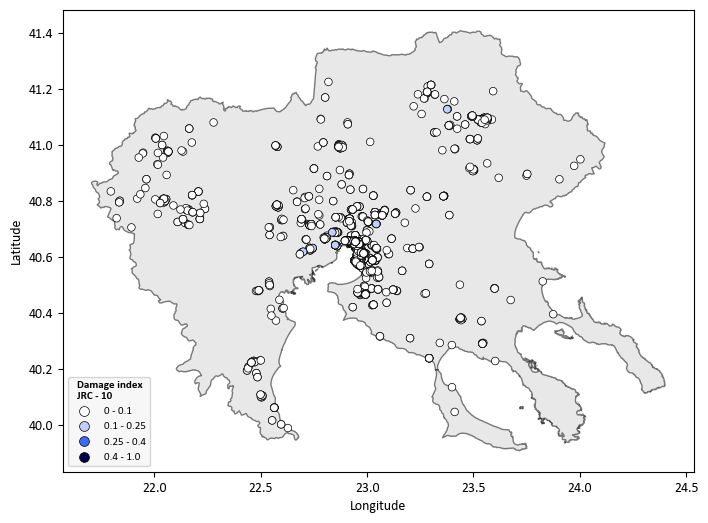

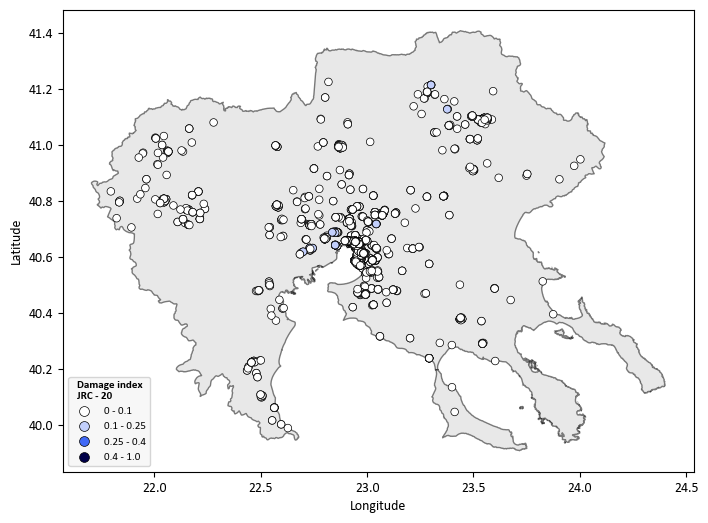

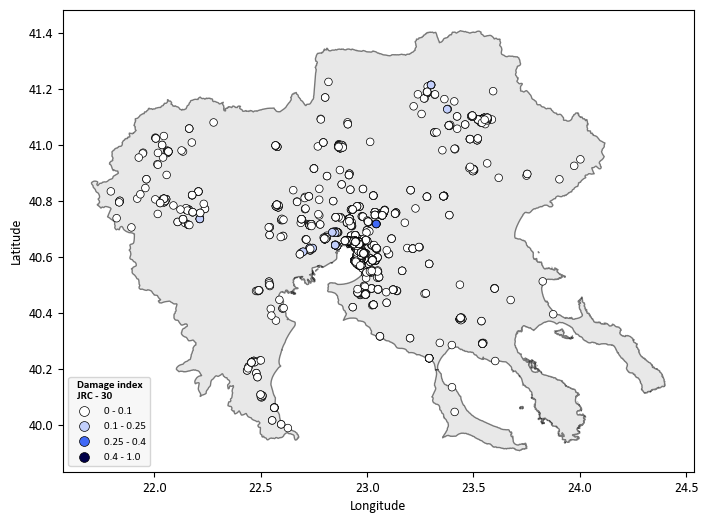

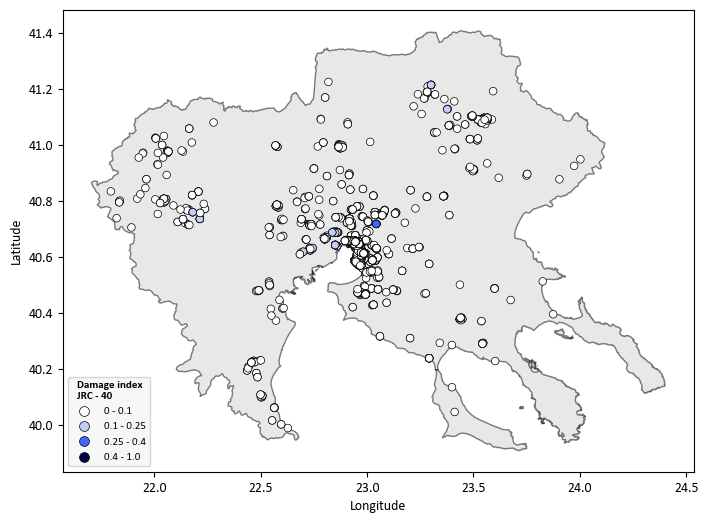

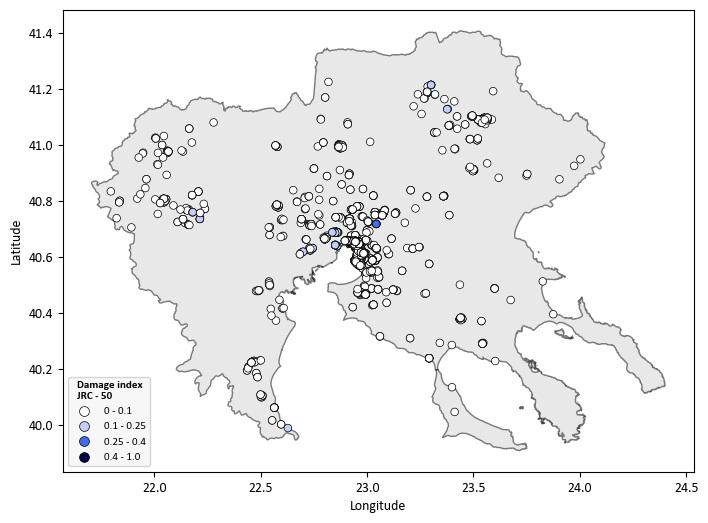

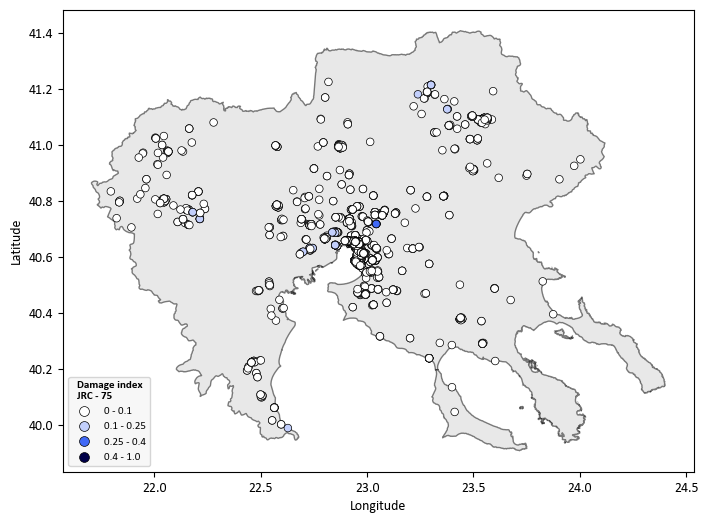

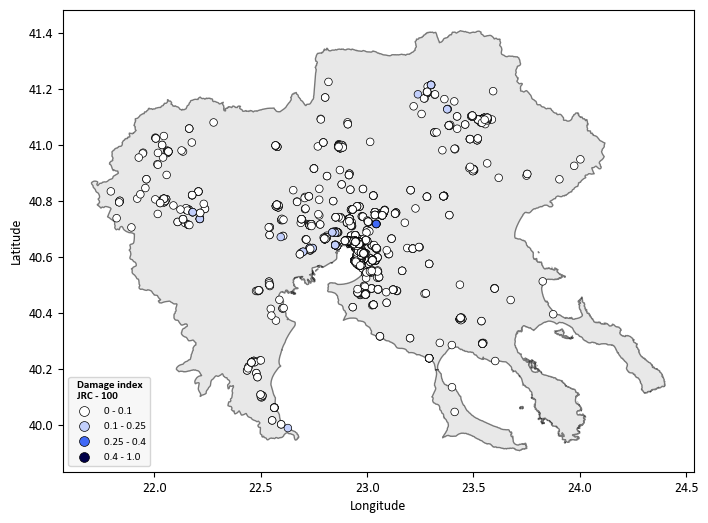

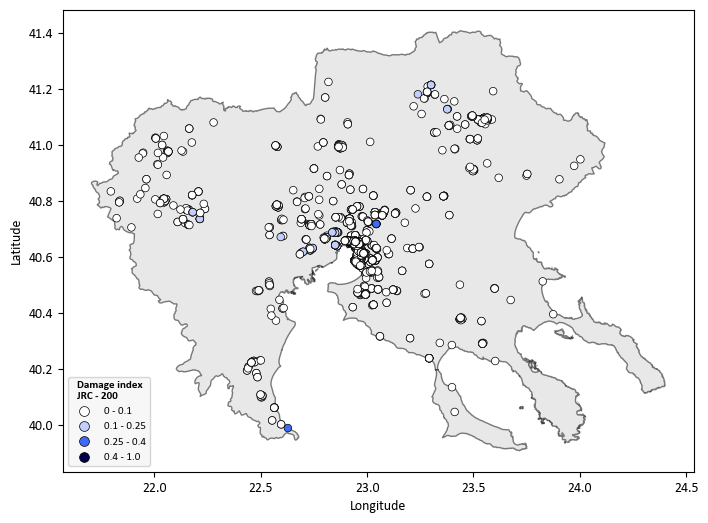

In [22]:
for j in JRC_periods:
    plot_DI(DI_flood, j, Scenaria=Scenaria)  

### Multi-Hazard Risk Assessment (Earthquakes and Floods)

This section extends the single-hazard seismic risk assessment by considering the effects of earthquake-triggered landslides.

Seismic hazard assessment: use of the newly developed open-access European Seismic Hazard maps (ESHM20, Danciu, et al., 2021) which provide PGA and spectral accelerations at different periods at bedrock for different return periods derived from probabilistic seismic hazard analysis (PSHA)
Estimate PGA and spectral accelerations at different periods (Sa(T)) at the ground surface for different return periods considering a detailed site model using Openquake engine 

Flood hazard assessment : Compound damage from independent flood and earthquake hazards is estimated by combining damage state probabilities (Arrighi et al. 2023):

$$P_{\text{COMB}}[LS \geq LS_i] = P_{E1}[LS \geq LS_i] + P_{E2}[LS \geq LS_i] - P_{E1}[LS \geq LS_i] \cdot P_{E2}[LS \geq LS_i]$$

where $P_{E1}$ is the flood exceedance probability and $P_{E2}$ the earthquake
exceedance probability (Eq. 6, Arrighi et al. 2023).

Flood depth is taken from JRC river flood maps (Dottori et al. 2021); seismic intensity (PGA, Sa(T)) from ESHM20 (Danciu et al. 2021) via OpenQuake with site amplification. Fragility functions follow ESRM20 (earthquakes) and Nofal & van de Lindt 2020 (floods). Results are compound loss maps for all 8 × 6 flood–earthquake return period combinations.



Load Single-Hazard Results

In [23]:
earthquakes_path = savepath /  f"Single-Hazard/Earthquakes/DI_Earthquakes_ESRM20_{asset}.csv"
floods_path = savepath /  f"Single-Hazard/Floods/DI_Floods_JRC_{asset}.csv"

# Load the CSV files into pandas DataFrames
df10 = pd.read_csv(earthquakes_path)
df11 = pd.read_csv(floods_path)

In [24]:
RPE_list = [73,102,475,1000,2500,5000]
RPF_list = [10,20,30,40,50,75,100,200]


# List of dataset names (DS1, DS2, DS3, DS4)
datasets = [1,2,3,4]

data = {'No': [0,1,2,3,4,5],
        'Return_Period': [73,102,475,1000,2500,5000],
        '1/years': [0.0137,0.0098,0.0021,0.001,0.0003,0.0001]
}

df_data = pd.DataFrame(data)

# Start DI_combined with metadata columns from df10
DI_combined = df10[[
    'Longitude', 'Latitude', 'id', 'Name', 'Counsil', 'Material',
    'Lateral Loading system', 'Code level', 'Floors',
    'Lateral Coefficiency', 'Intensity', 'Typology', 'Area'
]].copy()


for RPE in RPE_list:
    freq_RPE = df_data.loc[df_data['Return_Period'] == RPE, '1/years'].values[0]
    
    for RPF in RPF_list:

        for dataset in datasets:
             try:
                combined_value = (
                    df10[f"CDF{dataset}-{freq_RPE}"] + df11[f"CDF{dataset}-{RPF}"] - df10[f"CDF{dataset}-{freq_RPE}"] * df11[f"CDF{dataset}-{RPF}"]
                )
            
                # Store the results in the new DataFrame
                DI_combined[f"PDS{dataset}_{RPE}-{RPF}"] = combined_value
             except KeyError:
                print(f"Missing data for CDF{dataset}-{freq_RPE} or CDF{dataset}-{RPF}")
                DI_combined[f"PDS{dataset}_{RPE}-{RPF}"] = None
        
        for index in range(len(DI_combined)):
            if df10['Material'].iloc[index] == 'Precast':
                DI_combined.at[index, f"DI_{RPE}-{RPF}"] = (
                    DI_combined.at[index, f"PDS1_{RPE}-{RPF}"] * 0.05 +
                    DI_combined.at[index, f"PDS2_{RPE}-{RPF}"] * 0.30 +
                    DI_combined.at[index, f"PDS3_{RPE}-{RPF}"] * 0.70 +
                    DI_combined.at[index, f"PDS4_{RPE}-{RPF}"] * 1
                )
            else:
                DI_combined.at[index, f"DI_{RPE}-{RPF}"] = (
                    DI_combined.at[index, f"PDS1_{RPE}-{RPF}"] * 0.05 +
                    DI_combined.at[index, f"PDS2_{RPE}-{RPF}"] * 0.15 +
                    DI_combined.at[index, f"PDS3_{RPE}-{RPF}"] * 0.60 +
                    DI_combined.at[index, f"PDS4_{RPE}-{RPF}"] * 1
                )
        


file_path = savepath /  f"Multi-hazard/Earthquakes & Floods/DI_Earthquakes_&_Floods_ESRM20_JRC_{asset}.csv"
DI_combined.to_csv(file_path, index=False)

# Display the resulting combined DataFrame
DI_combined.head()

,Longitude,Latitude,id,Name,Counsil,Material,Lateral Loading system,Code level,Floors,Lateral Coefficiency,...,PDS1_5000-100,PDS2_5000-100,PDS3_5000-100,PDS4_5000-100,DI_5000-100,PDS1_5000-200,PDS2_5000-200,PDS3_5000-200,PDS4_5000-200,DI_5000-200
0,22.538980,40.511320,72,3ο Νηπιαγωγείο Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,Precast,LFINF: infilled frame,CDH,1,NaN,...,0.216825,0.002774,0.000004,7.202889e-10,0.011676,0.216825,0.002774,0.000004,7.202889e-10,0.011676
1,22.543110,40.498490,73,1ο Δημοτικό Αιγινίου,ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,1,10.0,...,0.092901,0.001004,0.000033,2.365594e-06,0.004818,0.092901,0.001004,0.000033,2.365594e-06,0.004818
2,22.911365,40.734834,82,1ο Νηπιαγωγείο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,MUR: unreinforced masonry,LWAL: load bearing wall,CDN,1,NaN,...,0.954285,0.627054,0.378239,2.390916e-01,0.607808,0.954285,0.627054,0.378239,2.390916e-01,0.607808
3,22.919226,40.723864,83,2ο Γυμνάσιο Ωραιοκάστρου,ΩΡΑΙΟΚΑΣΤΡΟΥ,CR: reinforced concrete,LFINF: infilled frame,CDH,3,15.0,...,0.778392,0.183462,0.035552,8.286710e-03,0.096057,0.778392,0.183462,0.035552,8.286710e-03,0.096057
4,22.993852,40.612094,84,3ο Δημοτικό Σχολείο Πυλαίας,ΠΥΛΑΙΑΣ-ΧΟΡΤΙΑΤΗ,CR: reinforced concrete,LDUAL: dual frame-wall system,CDH,2,NaN,...,0.580276,0.071731,0.015002,4.576872e-03,0.053352,0.580276,0.071731,0.015002,4.576872e-03,0.053352
